In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor


In [ ]:
df = pd.read_excel("/content/Sales Dataset (1).xlsx")
print("Original Shape:", df.shape)

df.head()

Original Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


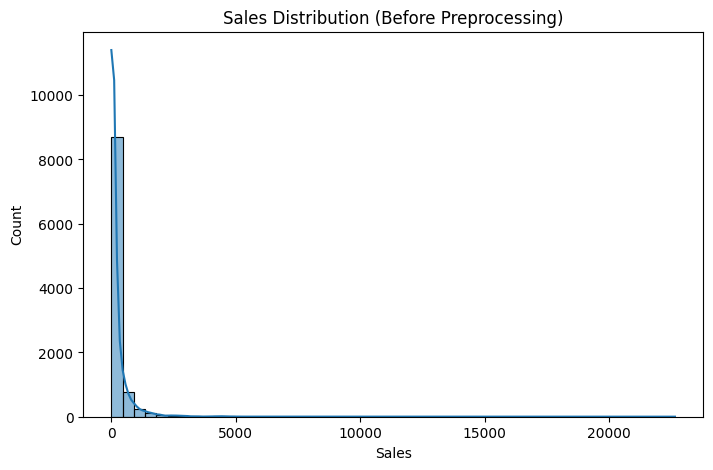

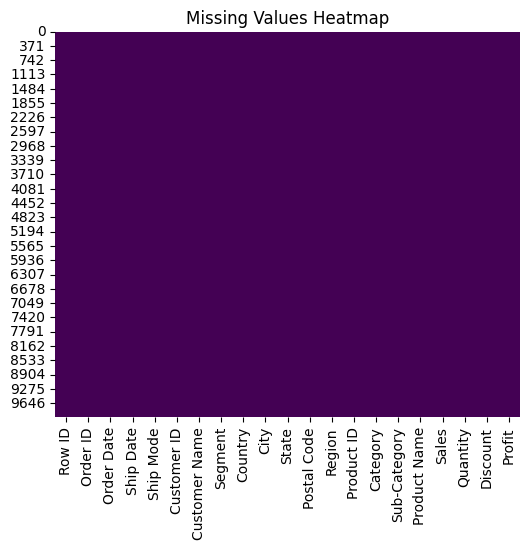

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Sales Distribution (Before Preprocessing)")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

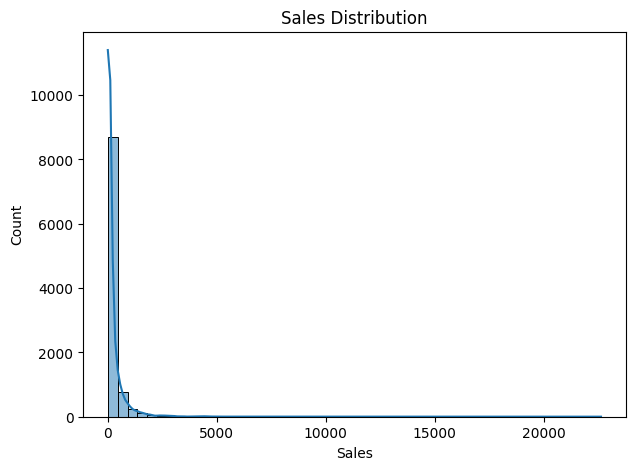

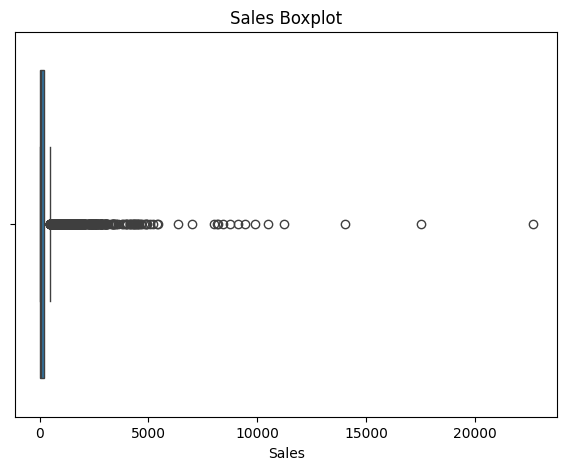

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(x=df["Sales"])
plt.title("Sales Boxplot")
plt.show()


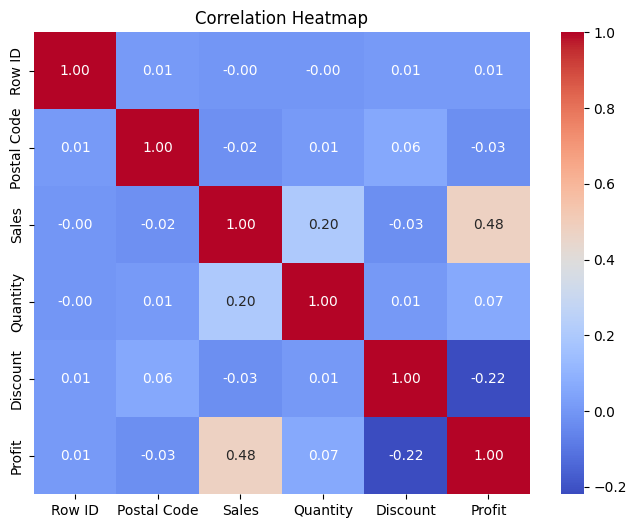

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()



/tmp/ipython-input-3723469425.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Category", y="Sales", data=df, estimator=np.mean, ci=None, palette="coolwarm")
/tmp/ipython-input-3723469425.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Sales", data=df, estimator=np.mean, ci=None, palette="coolwarm")


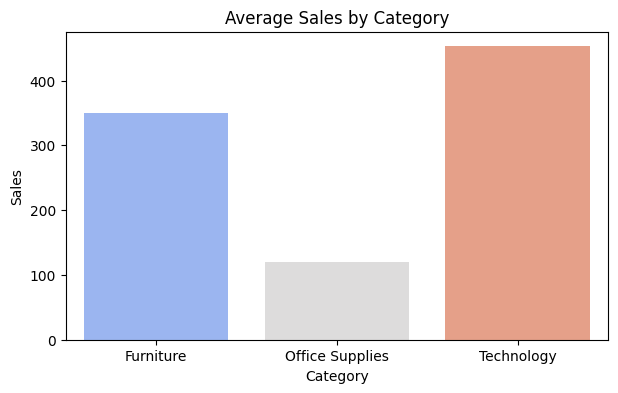

/tmp/ipython-input-3723469425.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Segment", y="Profit", data=df, estimator=np.mean, ci=None, palette="magma")
/tmp/ipython-input-3723469425.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Segment", y="Profit", data=df, estimator=np.mean, ci=None, palette="magma")


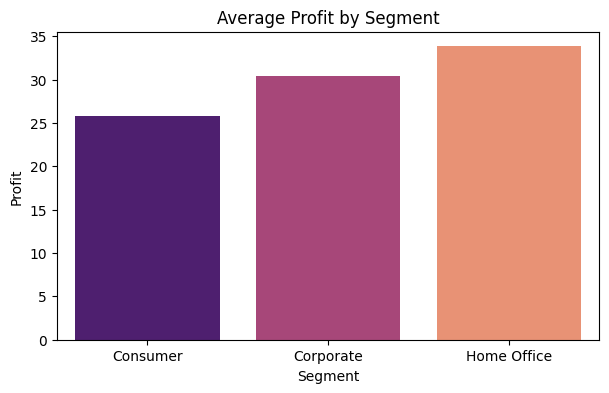

In [ ]:
if "Category" in df.columns and "Sales" in df.columns:
    plt.figure(figsize=(7,4))
    sns.barplot(x="Category", y="Sales", data=df, estimator=np.mean, ci=None, palette="coolwarm")
    plt.title("Average Sales by Category")
    plt.show()

if "Segment" in df.columns and "Profit" in df.columns:
    plt.figure(figsize=(7,4))
    sns.barplot(x="Segment", y="Profit", data=df, estimator=np.mean, ci=None, palette="magma")
    plt.title("Average Profit by Segment")
    plt.show()


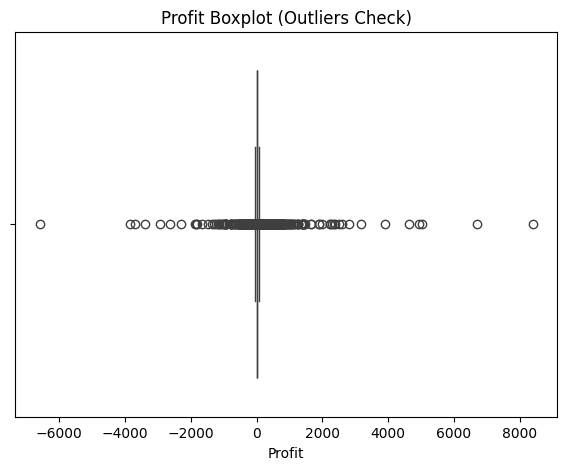

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x=df["Profit"])
plt.title("Profit Boxplot (Outliers Check)")
plt.show()


In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipython-input-2100834643.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2100834643.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
cols_to_drop = ["Row ID", "Order ID", "Customer ID", "Customer Name",
                "Product ID", "Product Name", "Order Date", "Ship Date"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print("After Cleaning Shape:", df.shape)

After Cleaning Shape: (9994, 13)


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
# import category_encoders as ce

# categorical_cols = df.select_dtypes(include="object").columns
# encoder = ce.BinaryEncoder(cols=categorical_cols, return_df=True)
# df = encoder.fit_transform(df)

In [ ]:
if "Profit" in df.columns and "Sales" in df.columns:
    df["Profit_Margin"] = df["Profit"] / (df["Sales"] + 1e-6)

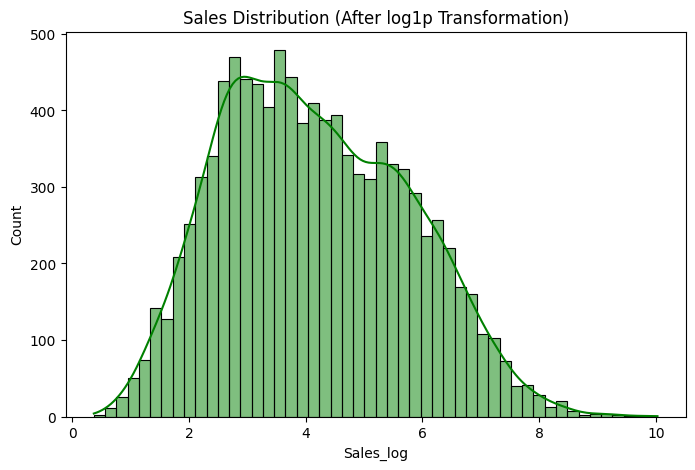

In [ ]:
df["Sales_log"] = np.log1p(df["Sales"])
X = df.drop(columns=["Sales", "Sales_log"])
y = df["Sales_log"]

# Visualize after transformation
plt.figure(figsize=(8,5))
sns.histplot(df["Sales_log"], bins=50, kde=True, color="green")
plt.title("Sales Distribution (After log1p Transformation)")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)


scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
xgb_tuned = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=5,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_train_pred = xgb_tuned.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

y_test_pred = xgb_tuned.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("\n📊 XGBoost Tuned Performance:")
print("Train RMSE:", round(train_rmse, 4), "| Train R²:", round(train_r2*100, 2), "%")
print("Test RMSE:", round(test_rmse, 4), "| Test R²:", round(test_r2*100, 2), "%")



📊 XGBoost Tuned Performance:
Train RMSE: 0.1572 | Train R²: 99.02 %
Test RMSE: 0.1948 | Test R²: 98.51 %
